<a href="https://www.kaggle.com/code/nadezhdaemelyanova/start-ml-final-project-catboost?scriptVersionId=312259302" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# установка зависимостей, которые требовались по заданию

!pip install fastapi==0.115.12, pandas==2.2.2, sqlalchemy==2.0.40
!pip install numpy==2.0.2, catboost==1.2.8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 51.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.44
    Uninstalling SQLAlchemy-2.0.44:
      Successfully uninstalled SQLAlchemy-2.0.44
  Attempting uninstall: starlette
    Found existing installation: starlette 0.50.0
    Uninstalling starlette-0.50.0:
      Successfully uninstalled starlette-0.50.0
  Attempting uninstall: fastapi
    Found existing installation: fastapi 0.123.10
    Uninstalling fastapi-0.123.10:
      Successfully uninstalled fastapi-0.123.10
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not in

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nadezhdaemelyanova/allcsv/all.csv', sep=';')
df = df.set_index('Unnamed: 0')
df.head()

,timestamp,user_id,post_id,action,target,gender,age,country,city,exp_group,os,source,text,topic
Unnamed: 0,,,,,,,,,,,,,,
0,2021-12-29 23:51:06,161289,879,view,0,1,18,Russia,Moscow,2,Android,organic,Youssou NDour wins music prize\n\nSenegalese m...,entertainment
1,2021-12-29 23:51:06,20156,3114,view,0,0,16,Russia,Asino,4,Android,ads,#MadhyaPradeshCM #ShivrajSinghChouhan tests po...,covid
2,2021-12-29 23:51:06,40577,305,view,0,1,37,Russia,Sursk,1,Android,ads,Call centre users lose patience\n\nCustomers t...,business
3,2021-12-29 23:51:06,134078,3927,view,0,1,38,Russia,Kemerovo,4,iOS,organic,Handwashing continues to play a huge role in s...,covid
4,2021-12-29 23:51:06,50842,5720,view,0,1,17,Russia,Leninsk-Kuznetskiy,4,iOS,ads,Nice combination of the giant monster and samu...,movie


In [8]:
post_text_df = df[['post_id', 'text', 'topic']].drop_duplicates().reset_index(drop=True)
post_text_df

,post_id,text,topic
0,879,Youssou NDour wins music prize\n\nSenegalese m...,entertainment
1,3114,#MadhyaPradeshCM #ShivrajSinghChouhan tests po...,covid
2,305,Call centre users lose patience\n\nCustomers t...,business
3,3927,Handwashing continues to play a huge role in s...,covid
4,5720,Nice combination of the giant monster and samu...,movie
...,...,...,...
6826,1259,Police probe BNP mosque leaflet\n\nPolice are ...,politics
6827,5011,"As most other reviewers seem to agree, this ad...",movie
6828,5152,This is one of the best movies I have seen in ...,movie
6829,4625,No likeable characters (the lead is a combinat...,movie


In [9]:
# работаем с переменной text

texts = post_text_df['text'].astype(str).tolist()

vectorizer = TfidfVectorizer(
    max_features=5000, 
    stop_words='english'
)

embeddings = vectorizer.fit_transform(texts)

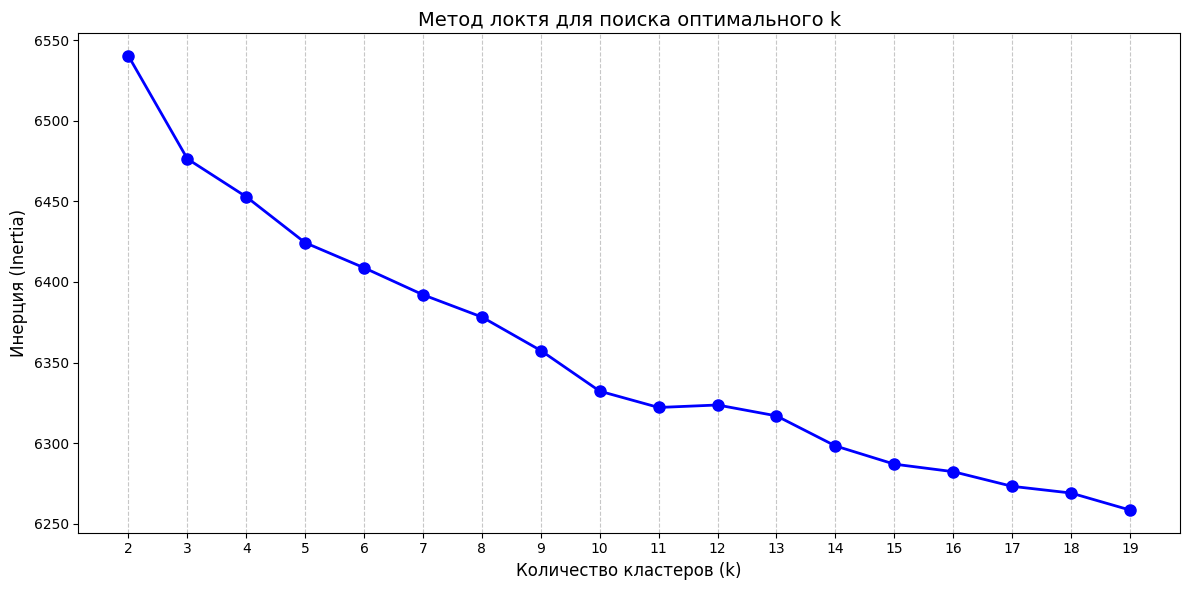

In [10]:
# используем метод локтя для определения оптимального количества кластеров

inertia = []
K = range(2, 20)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    kmeans.fit(embeddings)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(K, inertia, 'bo-', linewidth=2, markersize=8)

plt.xlabel('Количество кластеров (k)', fontsize=12)
plt.ylabel('Инерция (Inertia)', fontsize=12)
plt.title('Метод локтя для поиска оптимального k', fontsize=14)
plt.xticks(K) 
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [11]:
# получаем кластеры

if 'cluster' in df.columns:
    df = df.drop(columns=['cluster'])

kmeans = KMeans(n_clusters=8, random_state=0, n_init='auto')
cluster_labels = kmeans.fit_predict(embeddings)
post_text_df['cluster'] = cluster_labels
df = df.merge(
    post_text_df[['post_id', 'cluster']], 
    on='post_id', 
    how='left'
)
print(df['cluster'].value_counts())

cluster
5    1416572
7    1101904
4     902237
6     785805
1     559665
2     557465
0     427204
3     139703
Name: count, dtype: int64


In [12]:
# cортировка по времени
df = df.sort_values('timestamp').reset_index(drop=True)

# разделение на train/val по времени, тк нам нужно предсказывать будущее
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
val_df = df.iloc[split_idx:].copy()

print(f"Train size: {len(train_df)}, Val size: {len(val_df)}")

Train size: 4712444, Val size: 1178111


In [13]:
# новые фичи для пользователей

# 1. favorite_topic: самый частый топик среди просмотренных постов
user_topic_counts = train_df.groupby(['user_id', 'topic']).size().reset_index(name='count')
user_fav_topic = user_topic_counts.loc[user_topic_counts.groupby('user_id')['count'].idxmax()]
user_fav_topic = user_fav_topic.set_index('user_id')['topic'].to_dict()

# 2. loyalty = лайки / просмотры
user_loyalty = train_df.groupby('user_id')['target'].mean().to_dict()

# 3. likes_ratio = сумма лайков пользователя / сумма лайков просмотренных постов
post_likes = train_df[train_df['target']==1].groupby('post_id').size().to_dict()
train_df['post_likes'] = train_df['post_id'].map(post_likes).fillna(0)
user_sum_likes = train_df.groupby('user_id')['target'].sum()
user_sum_post_likes = train_df.groupby('user_id')['post_likes'].sum()
user_likes_ratio = (user_sum_likes / user_sum_post_likes).fillna(0).to_dict()

In [14]:
# новая фича для постов

# 4. likes to views ratio = количество лайков поста / количество просмотров поста
post_views = train_df.groupby('post_id').size()
post_likes_total = train_df[train_df['target']==1].groupby('post_id').size()
post_likes_to_views = (post_likes_total / post_views).fillna(0).to_dict()

In [15]:
# сохраняем средние значения для новых объектов, чтобы заполнить ими пропуски
# (например, когда пользователь ни разу ничего не лайкнул)

mean_loyalty = np.mean(list(user_loyalty.values()))
mean_likes_ratio = np.mean(list(user_likes_ratio.values()))
mean_likes_to_views = np.mean(list(post_likes_to_views.values()))
most_common_topic = train_df['topic'].mode()[0]

In [16]:
# применяем к train, val и исходному датасету
def enrich_features(df, user_fav_topic, user_loyalty, user_likes_ratio, post_likes_to_views,
                    mean_loyalty, mean_likes_ratio, mean_likes_to_views, most_common_topic):
    df = df.copy()
    # favorite_topic
    df['favorite_topic'] = df['user_id'].map(user_fav_topic).fillna(most_common_topic)
    # loyalty
    df['loyalty'] = df['user_id'].map(user_loyalty).fillna(mean_loyalty)
    # likes_ratio
    df['likes_ratio'] = df['user_id'].map(user_likes_ratio).fillna(mean_likes_ratio)
    # likes_to_views_ratio для поста
    df['likes_to_views_ratio'] = df['post_id'].map(post_likes_to_views).fillna(mean_likes_to_views)
    return df

train_df = enrich_features(train_df, user_fav_topic, user_loyalty, user_likes_ratio,
                            post_likes_to_views, mean_loyalty, mean_likes_ratio,
                            mean_likes_to_views, most_common_topic)

val_df = enrich_features(val_df, user_fav_topic, user_loyalty, user_likes_ratio,
                            post_likes_to_views, mean_loyalty, mean_likes_ratio,
                            mean_likes_to_views, most_common_topic)

df = enrich_features(df, user_fav_topic, user_loyalty, user_likes_ratio,
                            post_likes_to_views, mean_loyalty, mean_likes_ratio,
                            mean_likes_to_views, most_common_topic)

In [17]:
# стандартизируем числовые признаки
user_num_cols = ['age', 'loyalty', 'likes_ratio']
item_num_cols = ['likes_to_views_ratio']

scaler_user = StandardScaler()
scaler_item = StandardScaler()

train_df[user_num_cols] = scaler_user.fit_transform(train_df[user_num_cols])
val_df[user_num_cols] = scaler_user.transform(val_df[user_num_cols])
df[user_num_cols] = scaler_user.transform(df[user_num_cols])

train_df[item_num_cols] = scaler_item.fit_transform(train_df[item_num_cols])
val_df[item_num_cols] = scaler_item.transform(val_df[item_num_cols])
df[item_num_cols] = scaler_item.transform(df[item_num_cols])

In [18]:
X_train = train_df.drop('target', axis=1)
y_train = train_df['target']

X_val = val_df.drop('target', axis=1)
y_val = val_df['target']

In [19]:
X_train.head()

,timestamp,user_id,post_id,action,gender,age,country,city,exp_group,os,source,text,topic,cluster,post_likes,favorite_topic,loyalty,likes_ratio,likes_to_views_ratio
0,2021-10-27 16:42:51,148233,1538,view,1,0.275431,Russia,Saint Petersburg,1,Android,organic,Ferguson urges Henry punishment\n\nSir Alex Fe...,sport,6,220,sport,-2.004112,-1.928728,0.865697
1,2021-10-27 16:42:51,107427,6230,view,1,-0.898397,Russia,Samara,4,iOS,organic,"Well...there were some great, creamy-smooth fa...",movie,7,42,movie,-2.004112,-1.928728,-1.109097
2,2021-10-27 16:42:51,155034,2195,view,0,-1.191854,Russia,Kazan,3,iOS,organic,Freeze on anti-spam campaign\n\nA campaign by ...,tech,0,50,tech,-2.004112,-1.928728,-0.959734
3,2021-10-27 16:42:51,51391,5242,view,0,-0.213664,Russia,Achinsk,0,iOS,ads,"Now that I have seen it, it was NOT what I was...",movie,2,53,movie,-2.004112,-1.928728,-0.520381
4,2021-10-27 16:42:51,65042,3860,view,1,2.818724,Ukraine,Kyiv,0,Android,ads,"Thanks to @TPolasara, we got the necessary doc...",covid,5,179,covid,-2.004112,-1.928728,0.459922


In [20]:
# признаки, влияющие наиболее сильно на результат по графику feature importance

top_names = ['topic', 'favorite_topic', 'loyalty', 'cluster', 'likes_ratio', 'likes_to_views_ratio', 'age']

In [21]:
X_train_top = X_train[top_names]
X_val_top = X_val[top_names]

In [22]:
X_val_top.head()

,topic,favorite_topic,loyalty,cluster,likes_ratio,likes_to_views_ratio,age
4712444,covid,movie,-0.914785,5,-0.904441,1.102227,-0.507121
4712445,movie,movie,-0.315655,7,-0.939950,-0.548700,-0.800578
4712446,movie,movie,-0.914785,7,-1.011796,0.073932,1.057983
4712447,movie,movie,-0.315655,7,-0.854246,-1.594924,-0.604940
4712448,sport,movie,1.065809,6,2.051060,0.183030,0.764526


In [ ]:
# # подбор гиперпараметров

# from catboost import CatBoostClassifier

# model = CatBoostClassifier(
#     iterations=50, 
#     border_count=32,
#     eval_metric='AUC:hints=skip_train~false',
#     random_seed=0,
#     class_weights=[1, 7],
#     cat_features=['topic', 'favorite_topic']
# )

# param_grid = {
#     'learning_rate': [0.01, 0.05, 0.1],
#     'depth': [4, 6, 8],
#     'l2_leaf_reg': [3, 5, 7]
# }

# grid_search_result = model.grid_search(
#     param_grid,
#     X=X_train_top,
#     y=y_train,
#     verbose=True,                
#     refit=True,               
#     partition_random_seed=0
# )

In [ ]:
# print(f"лучшие параметры: {grid_search_result['params']}")

In [27]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    learning_rate=0.1,
    depth=8,
    l2_leaf_reg=3,
    iterations=500,
    border_count=254,
    eval_metric='AUC:hints=skip_train~false',
    random_seed=1,
    class_weights=[1, 6],
    cat_features=['topic', 'favorite_topic'],
    task_type='GPU',
).fit(X_train_top, y_train)

from sklearn.metrics import classification_report

report = classification_report(y_val, model.predict(X_val_top), output_dict=True)
print(pd.DataFrame(report).T.round(3))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	learn: 0.6850175	total: 349ms	remaining: 2m 54s
1:	total: 609ms	remaining: 2m 31s
2:	total: 878ms	remaining: 2m 25s
3:	total: 1.15s	remaining: 2m 23s
4:	total: 1.44s	remaining: 2m 22s
5:	learn: 0.6931646	total: 1.73s	remaining: 2m 22s
6:	total: 1.99s	remaining: 2m 19s
7:	total: 2.28s	remaining: 2m 20s
8:	total: 2.55s	remaining: 2m 19s
9:	total: 2.83s	remaining: 2m 18s
10:	learn: 0.6949045	total: 3.14s	remaining: 2m 19s
11:	total: 3.41s	remaining: 2m 18s
12:	total: 3.67s	remaining: 2m 17s
13:	total: 3.94s	remaining: 2m 16s
14:	total: 4.22s	remaining: 2m 16s
15:	learn: 0.6956983	total: 4.49s	remaining: 2m 15s
16:	total: 4.75s	remaining: 2m 14s
17:	total: 5s	remaining: 2m 13s
18:	total: 5.26s	remaining: 2m 13s
19:	total: 5.52s	remaining: 2m 12s
20:	learn: 0.6976824	total: 5.8s	remaining: 2m 12s
21:	total: 6.06s	remaining: 2m 11s
22:	total: 6.3s	remaining: 2m 10s
23:	total: 6.54s	remaining: 2m 9s
24:	total: 6.77s	remaining: 2m 8s
25:	learn: 0.6986778	total: 7.05s	remaining: 2m 8s
26:	to

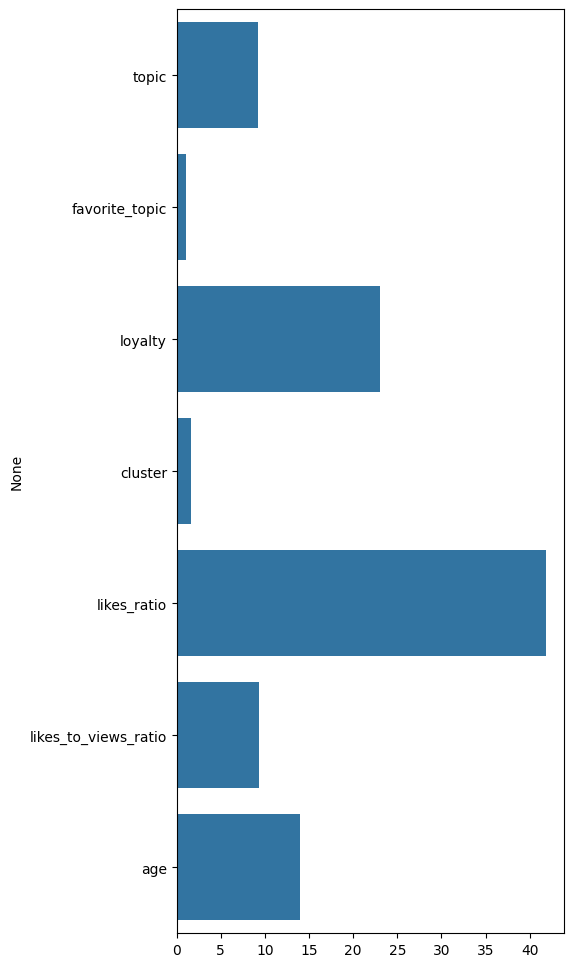

In [28]:
fig = plt.figure()
fig.set_size_inches(5,12)

sns.barplot(x=model.feature_importances_,
            y=X_train_top.columns)

plt.show()

In [29]:
# сохраняем модель, проверяем что она работает

model.save_model('model_control', format="cbm")

from_file = CatBoostClassifier() 

from_file.load_model("model_control")

print(from_file.predict(X_val_top))

[0 0 0 ... 0 0 0]


In [ ]:
# загрузка информации о юзерах в БД

user_cols = ['favorite_topic', 'loyalty', 'likes_ratio', 'age']
user_cols.append('user_id')
data_users = df.copy()[user_cols].drop_duplicates('user_id')

engine = create_engine(
    "postgresql://login:password@"
    "postgres.lab.karpov.courses:6432/startml"
)

with engine.connect() as connection:
    data_users.to_sql('nadezhda01em_users_control_1', con=connection)

In [ ]:
# загрузка информации о постах в БД

data_posts = post_text_df.merge(df_reserved[['likes_to_views_ratio', 'post_id']], 
                                on='post_id', how='left').drop_duplicates('post_id')

engine = create_engine(
    "postgresql://login:password@"
    "postgres.lab.karpov.courses:6432/startml"
)

with engine.connect() as connection:
    data_posts.to_sql('nadezhda01em_posts_control_1', con=connection)